# Pre processing and feature extraction

In this notebook, we are going to explore preprocessing techniques and feature extraction methods that we think that are going to be suitable for the needs of this emotion classification task.

Our dataset contains both textual content and rich metadata that need to be effectively combined

### Imports and dataset Loading

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pickle
from gensim.models import Word2Vec
import pandas as pd
import warnings
import ast
warnings.filterwarnings('ignore')


# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data, prepare_dataset_splits
from emotion_classifier.preprocessing import preprocess_text, clean_text, preprocess_and_replace
from emotion_classifier.features import (
    load_nrc_emotion_lexicon,
    extract_lexicon_features,
    combine_categorical_features,
    apply_one_hot_encoding,
    create_one_hot_features,
    encode_secondary_emotions,
    normalize_intensity
)

In [2]:
# Load dataset
train_df, test_df = load_raw_data()
print(f"Loaded dataset with {len(train_df)} samples")

# Create train/validation/test splits if not already done
try:
    train_df, val_df, test_df = prepare_dataset_splits(train_df)
    print(f"Created splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
except Exception as e:
    print(f"Using existing splits: {e}")
    
# Preview the data
train_df.head()

# Make copies of original dataframes for different processing approaches
train_df_orig = train_df.copy()
val_df_orig = val_df.copy()
test_df_orig = test_df.copy()

Loaded dataset with 1874 samples
Created splits: train=1124, val=375, test=375


---

## 1. Text Cleaning

We'll explore different preprocessing techniques for the text data to determine the optimal approach for emotion classification.

The optimal preprocessing pipeline depends on the specific classification task. For sentiment analysis, we need to preserve words that might carry emotional content while reducing noise and standardizing format.

#### 1.1 Explore basic text cleaning approaches

In [3]:
# Let's examine a sample text before and after cleaning
sample_text = train_df.iloc[10]['text']
print(f"Original text: {sample_text}")

# Basic cleaning (lowercase, remove punctuation and numbers and emojis)
cleaned_text = clean_text(
    sample_text,
    lower=True,
    decontract=True,
    remove_punctuation=True,
    remove_emoji=True,
    remove_digits=True
)
print(f"Basic cleaning: {cleaned_text}")

# Process with different configurations to compare approaches
tokens_with_stops = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=False,
    stemming=False,
    lemmatization=False
)
print(f"After tokenization (with stopwords): {' '.join(tokens_with_stops)}")

tokens_no_stops = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=False
)
print(f"After stopword removal: {' '.join(tokens_no_stops)}")

tokens_stemmed = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=True,
    lemmatization=False
)
print(f"Stemming: {' '.join(tokens_stemmed)}")

tokens_lemmatized = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=True
)
print(f"Lemmatization: {' '.join(tokens_lemmatized)}")

Original text: I’m proud of how far I’ve come in my fitness journey, but I know there’s still more to achieve. 💪
Basic cleaning: i am proud of how far i have come in my fitness journey but i know there is still more to achieve
After tokenization (with stopwords): i am proud of how far i have come in my fitness journey but i know there is still more to achieve
After stopword removal: proud far come fitness journey know still achieve
Stemming: proud far come fit journey know still achiev
Lemmatization: proud far come fitness journey know still achieve


#### 1.2 Analysis

Analyze the impact of text preprocessing on corpus, statistics for a small sample.

Here we quantitatively evaluate how different preprocessing configurations affect our corpus statistics, including:

Total token count
Unique token count (vocabulary size)
Vocabulary richness (unique tokens / total tokens)
Average text length
These metrics help us balance information preservation with noise reduction. A significantly reduced vocabulary may indicate loss of important distinctions, while preserving too much noise can obscure meaningful patterns.

In [4]:
def analyze_preprocessing_impact(texts, preproc_params_list, param_names):
    """Analyze how different preprocessing parameters affect the corpus."""
    results = []
    
    for i, params in enumerate(preproc_params_list):
        # Apply preprocessing
        processed_texts = []
        for text in texts:
            tokens = preprocess_text(text, **params)
            processed_texts.append(" ".join(tokens))
        
        # Calculate statistics
        total_tokens = 0
        all_tokens = []
        for text in processed_texts:
            tokens = text.split()
            total_tokens += len(tokens)
            all_tokens.extend(tokens)
        
        unique_tokens = len(set(all_tokens))
        vocabulary_richness = unique_tokens / total_tokens if total_tokens > 0 else 0
        avg_text_length = total_tokens / len(processed_texts) if processed_texts else 0
        
        results.append({
            'Configuration': param_names[i],
            'Total Tokens': total_tokens,
            'Unique Tokens': unique_tokens,
            'Vocabulary Richness': vocabulary_richness,
            'Avg Text Length': avg_text_length
        })
    
    return pd.DataFrame(results)

# Define different preprocessing configurations to test
preproc_configs = [
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': False, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': True, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': True},
]

config_names = [
    'Basic Cleaning',
    'With Stopword Removal',
    'With Stemming',
    'With Lemmatization'
]

# Sample a subset for faster analysis
sample_size = min(1000, len(train_df))
sampled_texts = train_df['text'].sample(sample_size, random_state=42).tolist()

# Run analysis
preprocessing_impact = analyze_preprocessing_impact(sampled_texts, preproc_configs, config_names)
preprocessing_impact

,Configuration,Total Tokens,Unique Tokens,Vocabulary Richness,Avg Text Length
0,Basic Cleaning,28105,2605,0.092688,28.105
1,With Stopword Removal,13135,2479,0.188732,13.135
2,With Stemming,13135,1857,0.141378,13.135
3,With Lemmatization,13135,2327,0.177160,13.135


#### 1.3 Final pipeline
Based on this, we'll use the following settings:
- Lowercasing
- Punctuation removal
- Decontractions
- Stopword removal
- Lemmatization (preferred over stemming since it have more unique tokens, that could help retaining more semantic context)

In [5]:
def preprocess_corpus(texts):
    """Apply our chosen preprocessing pipeline to the entire corpus."""
    processed_texts = []
    for text in texts:
        tokens = preprocess_text(
            text,
            lower=True,
            decontract=True,
            remove_punct=True, 
            remove_digits=True,
            remove_stops=True,
            stemming=False,
            lemmatization=True
        )
        processed_texts.append(" ".join(tokens))
    return processed_texts

# Apply preprocessing to our dataset splits
train_processed = preprocess_corpus(train_df['text'].tolist())
val_processed = preprocess_corpus(val_df['text'].tolist())
test_processed = preprocess_corpus(test_df['text'].tolist())

print(f"Processed {len(train_processed)} training texts")
print(f"Processed {len(val_processed)} validation texts")
print(f"Processed {len(test_processed)} test texts")

# Compare original and processed text for a sample
for i in range(3):
    print(f"\nOriginal: {train_df['text'].iloc[i]}")
    print(f"Processed: {train_processed[i]}")

Processed 1124 training texts
Processed 375 validation texts
Processed 375 test texts

Original: Posted my artwork online for the first time, and I’m so nervous about how people will react. But I’m also proud of myself for putting it out there. 🎨
Processed: posted artwork online first time nervous people react also proud putting

Original: I’m so proud of my progress in therapy. It hasn’t been easy, but every step feels like a victory. I still have a long way to go, but I’m starting to see the light at the end of the tunnel. 💡
Processed: proud progress therapy easy every step feel like victory still long way go starting see light end tunnel

Original: I’m happy that I’m learning something new, but I also feel overwhelmed by the amount of work it’s taking. 📚
Processed: happy learning something new also feel overwhelmed amount work taking


---
## 2. Categorical Feature Processing

Our dataset contains rich categorical metadata beyond the text itself. These categorical features (primary_emotion, secondary_emotions, meta_emotions, interaction_style, context) potentially provide valuable signal for sentiment classification.

Categorical features present unique challenges:
- They can't be directly used by most machine learning algorithms
- They may have complex relationships with the target sentiment
- Some fields (like secondary_emotions) contain multiple values per instance

We explore two complementary approaches for processing these features:
- **Textual representation**: Combining categorical values into text strings that can be processed like the main content
- **Numerical encoding**: Converting categories directly to numerical features through one-hot and multi-hot encoding, except for meta_emotions because it contains 1659 unique emotional expressions, which would create an extremely high-dimensional and sparse feature space and would likely lead to overfitting.

#### 2.1. Combine Categorical Features into Text

This approach treats categorical features as additional textual content. By combining categorical values into a concated string, we can apply the same NLP techniques (Bag-of-Words, TF-IDF, Word2Vec) that we use for the main text content.

In [6]:
categorical_columns = ['primary_emotion', 'secondary_emotions', 'meta_emotions', 'interaction_style', 'context']

# Create combined text from categorical features
train_categorical_text = combine_categorical_features(train_df, categorical_columns)
val_categorical_text = combine_categorical_features(val_df, categorical_columns)
test_categorical_text = combine_categorical_features(test_df, categorical_columns)

# Preprocess the combined categorical text
train_categorical_processed = preprocess_corpus(train_categorical_text)
val_categorical_processed = preprocess_corpus(val_categorical_text)
test_categorical_processed = preprocess_corpus(test_categorical_text)

# Display samples of the combined and processed categorical text
print("Sample of combined categorical text features:")
for i in range(3):
    print(f"\nOriginal categorical columns: {[train_df[col].iloc[i] for col in categorical_columns]}")
    print(f"Combined categorical text: {train_categorical_text[i]}")
    print(f"Processed categorical text: {train_categorical_processed[i]}")

Sample of combined categorical text features:

Original categorical columns: ['Pride', "['Nervousness', 'Gratitude']", "['Reflection on courage', 'Commitment to creative growth']", 'Encouraging', 'Creativity']
Combined categorical text: Pride ['Nervousness', 'Gratitude'] ['Reflection on courage', 'Commitment to creative growth'] Encouraging Creativity
Processed categorical text: pride nervousness gratitude reflection courage commitment creative growth encouraging creativity

Original categorical columns: ['Pride', "['Hope', 'Gratitude']", "['Reflection on emotional resilience', 'Commitment to healing']", 'Empowering', 'Mental Health']
Combined categorical text: Pride ['Hope', 'Gratitude'] ['Reflection on emotional resilience', 'Commitment to healing'] Empowering Mental Health
Processed categorical text: pride hope gratitude reflection emotional resilience commitment healing empowering mental health

Original categorical columns: ['Excitement', "['Stress', 'Anticipation']", "['Reflectio

### 2.2 One-Hot Encoding for Categorical Features
We'll apply one-hot encoding to capture the direct categorical relationships

In [7]:
columns_to_encode = ['primary_emotion', 'interaction_style', 'context']

# Create one-hot encoded features for training data
X_train_onehot, onehot_encoder = create_one_hot_features(train_df, columns_to_encode)

# Transform validation and test data using the same encoder
X_val_onehot = apply_one_hot_encoding(val_df, onehot_encoder, columns_to_encode)
X_test_onehot = apply_one_hot_encoding(test_df, onehot_encoder, columns_to_encode)

print(f"One-hot encoded features shape: {X_train_onehot.shape}")
print(f"Number of unique categories encoded: {len(onehot_encoder.categories_)}")
print(f"Feature sparsity: {X_train_onehot.nnz / (X_train_onehot.shape[0] * X_train_onehot.shape[1]):.6f}")

# Sample of encoded categories
print("\nSample of encoded categories:")
for i, col in enumerate(columns_to_encode):
    print(f"{col}: {onehot_encoder.categories_[i][:5]} ... (total: {len(onehot_encoder.categories_[i])})")

One-hot encoded features shape: (1124, 233)
Number of unique categories encoded: 3
Feature sparsity: 0.012876

Sample of encoded categories:
primary_emotion: ['Accomplishment' 'Admiration' 'Amazement' 'Ambivalence' 'Anger'] ... (total: 84)
interaction_style: ['Activating' 'Adventurous' 'Affectionate' 'Analytical' 'Assertive'] ... (total: 24)
context: ['Achievement' 'Achievement (Sports)' 'Activism' 'Adventure' 'Art'] ... (total: 125)


### 2.3 Handle Secondary Emotions Separately

Secondary emotions present a special challenge because each instance can have multiple values. We implement multi-hot encoding, where multiple categories can be active (set to 1) simultaneously.

In [8]:
# Since secondary_emotions is a list field, we'll process it differently
# First, let's find all unique secondary emotions
all_secondary_emotions = set()
for emotions in train_df['secondary_emotions']:
    if isinstance(emotions, list):
        all_secondary_emotions.update(emotions)
    elif isinstance(emotions, str) and emotions.startswith('['):
        # Handle string representations of lists
        try:
            emotion_list = ast.literal_eval(emotions)
            all_secondary_emotions.update(emotion_list)
        except:
            pass

print(f"Number of unique secondary emotions: {len(all_secondary_emotions)}")

# Create multi-hot encoding for secondary emotions


# Create multi-hot encoding for secondary emotions
X_train_secondary = encode_secondary_emotions(train_df, list(all_secondary_emotions))
X_val_secondary = encode_secondary_emotions(val_df, list(all_secondary_emotions))
X_test_secondary = encode_secondary_emotions(test_df, list(all_secondary_emotions))

print(f"Secondary emotions encoding shape: {X_train_secondary.shape}")
print(f"Average secondary emotions per example: {X_train_secondary.sum(axis=1).mean():.2f}")

# Combine one-hot encoding with secondary emotions multi-hot encoding
X_train_cat_encoded = np.hstack([X_train_onehot.toarray(), X_train_secondary])
X_val_cat_encoded = np.hstack([X_val_onehot.toarray(), X_val_secondary])
X_test_cat_encoded = np.hstack([X_test_onehot.toarray(), X_test_secondary])

print(f"Combined categorical encoding shape: {X_train_cat_encoded.shape}")

Number of unique secondary emotions: 110
Secondary emotions encoding shape: (1124, 110)
Average secondary emotions per example: 2.00
Combined categorical encoding shape: (1124, 343)


#### 2.4. Normalize intensity values
Since intensity is a numerical value, we'll normalize it to [0-1] range

In [9]:
# Apply normalization
train_intensity_norm = normalize_intensity(train_df)
val_intensity_norm = normalize_intensity(val_df)
test_intensity_norm = normalize_intensity(test_df)

print("\nSample of normalized intensity values:")
display(pd.DataFrame({
    'Original Intensity': train_df['intensity'].head(),
    'Normalized Intensity': train_intensity_norm.head()
}))

# Convert to proper feature arrays
X_train_intensity = train_intensity_norm.values.reshape(-1, 1)
X_val_intensity = val_intensity_norm.values.reshape(-1, 1)
X_test_intensity = test_intensity_norm.values.reshape(-1, 1)

# Add intensity to the categorical features
X_train_cat_full = np.hstack([X_train_cat_encoded, X_train_intensity])
X_val_cat_full = np.hstack([X_val_cat_encoded, X_val_intensity])
X_test_cat_full = np.hstack([X_test_cat_encoded, X_test_intensity])

print(f"Full categorical features shape (with intensity): {X_train_cat_full.shape}")


Sample of normalized intensity values:


,Original Intensity,Normalized Intensity
801,8,0.8
1074,8,0.8
1458,7,0.7
127,8,0.8
1402,8,0.8


Full categorical features shape (with intensity): (1124, 344)


## 3. Text Feature Extraction for Main Text

Now we'll create different representations of the main text data.

We implement multiple complementary approaches, each capturing different aspects of text:
- Statistical approaches (BoW, TF-IDF): Capture word frequency and importance
- Semantic approaches (Word2Vec): Capture word meaning and relationships
- Knowledge-based approaches (NRC Lexicon): Incorporate external knowledge about emotional language
- Each approach has distinct advantages for sentiment classification:

### 3.1 Bag-of-Words Feature Extraction for Main Text

We implement Bag-of-Words (BoW) representation with a minimum document frequency of 2
to filter out very rare terms that might introduce noise.

In [10]:
bow_vectorizer = CountVectorizer(min_df=2, max_features=5000)
bow_vectorizer.fit(train_processed)

X_train_bow = bow_vectorizer.transform(train_processed)
X_val_bow = bow_vectorizer.transform(val_processed)
X_test_bow = bow_vectorizer.transform(test_processed)

print(f"BoW Feature Matrix Shape: {X_train_bow.shape}")
print(f"Vocabulary Size: {len(bow_vectorizer.vocabulary_)}")
print(f"Feature Density: {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.6f}")

BoW Feature Matrix Shape: (1124, 1420)
Vocabulary Size: 1420
Feature Density: 0.008558


### 3.2 TF-IDF Feature Extraction for Main Text
We implement TF-IDF vectorization with the same parameter settings as BoW for direct comparison.

In [11]:
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_features=5000)
tfidf_vectorizer.fit(train_processed)

X_train_tfidf = tfidf_vectorizer.transform(train_processed)
X_val_tfidf = tfidf_vectorizer.transform(val_processed)
X_test_tfidf = tfidf_vectorizer.transform(test_processed)

print(f"TF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")
print(f"Feature Density: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.6f}")

TF-IDF Feature Matrix Shape: (1124, 1420)
Feature Density: 0.008558


#### 3.3. Word2Vec Feature Extraction

Convert text to tokenized lists for Word2Vec

We implement document-level embeddings by averaging the word vectors for all words in a document

In [12]:
sentences = [text.split() for text in train_processed]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1  # Skip-gram model
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv.key_to_index)}")

# Function to create document embeddings by averaging word vectors
def create_doc_vectors(texts, model):
    doc_vectors = []
    for text in texts:
        tokens = text.split()
        token_vectors = [model.wv[word] for word in tokens if word in model.wv]
        
        if token_vectors:
            doc_vector = np.mean(token_vectors, axis=0)
        else:
            # For documents with no known words, use a zero vector
            doc_vector = np.zeros(model.wv.vector_size)
            
        doc_vectors.append(doc_vector)
    
    return np.array(doc_vectors)

# Create document vectors for main text
X_train_w2v = create_doc_vectors(train_processed, w2v_model)
X_val_w2v = create_doc_vectors(val_processed, w2v_model)
X_test_w2v = create_doc_vectors(test_processed, w2v_model)

print(f"Word2Vec document embeddings shape: {X_train_w2v.shape}")

Word2Vec vocabulary size: 1422
Word2Vec document embeddings shape: (1124, 100)


#### 3.4 NRC Emotion Lexicon Features

The NRC Emotion Lexicon is a valuable resource for emotion analysis that maps words to emotions and sentiments. Created by Saif Mohammad and Peter Turney, it contains approximately 14,000 word-emotion associations covering 10 categories:

- 8 basic emotions: anger, fear, anticipation, trust, surprise, sadness, joy, and disgust
- 2 sentiments: negative and positive

**How Lexicon Features Work:**

1. The lexicon is downloaded and processed to create a dictionary mapping each emotion to its associated words.

2. For each text in our dataset, we count how many words match each emotion category in the lexicon.

3. These counts become features (10 dimensions per text) that directly capture emotional content based on expert-curated word-emotion associations.

Using the full NRC lexicon provides several benefits:

1. **Comprehensive coverage**: With thousands of emotion-word associations, we can detect subtle emotional signals in diverse texts.

2. **Nuanced emotion detection**: The lexicon captures a wide range of emotional concepts, including complex emotions through combinations of basic categories.

3. **Domain expertise**: The lexicon encodes human knowledge about emotional language, complementing the statistical patterns learned from our specific dataset.

These lexicon-based features provide a powerful signal that helps the model identify emotional content even when it's expressed through uncommon vocabulary or subtle phrasing.

Loading NRC Emotion Lexicon from disk...
Lexicon features shape: (1124, 10)
Emotions in lexicon: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']


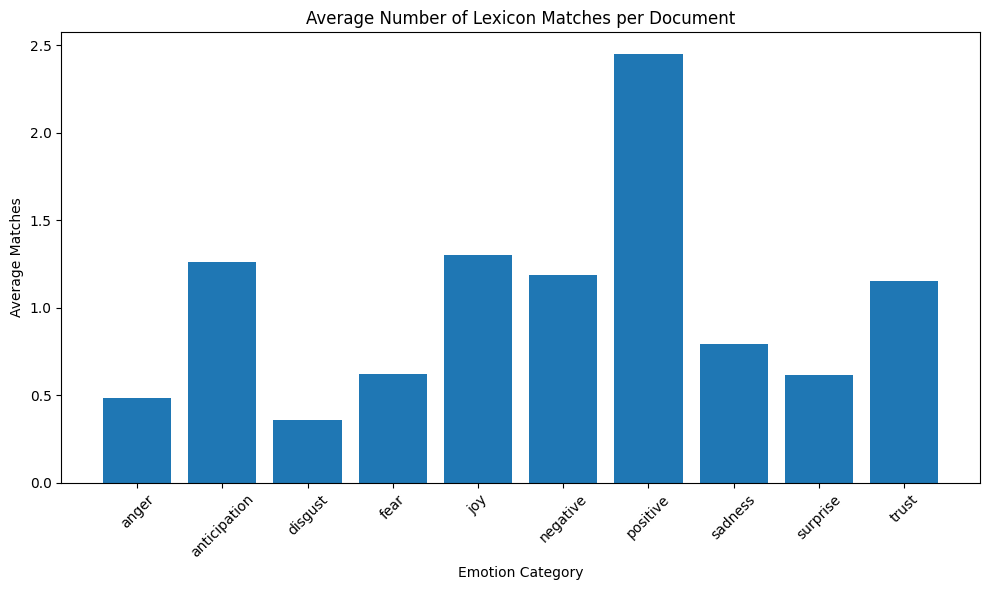

In [13]:
# Load the full NRC Emotion Lexicon
emotion_lexicons = load_nrc_emotion_lexicon()

# Extract lexicon features for main text
X_train_lex = extract_lexicon_features(train_processed, emotion_lexicons)
X_val_lex = extract_lexicon_features(val_processed, emotion_lexicons)
X_test_lex = extract_lexicon_features(test_processed, emotion_lexicons)

print(f"Lexicon features shape: {X_train_lex.shape}")
print(f"Emotions in lexicon: {list(emotion_lexicons.keys())}")

# Calculate average lexicon matches per document
avg_matches = X_train_lex.mean(axis=0)
emotion_names = list(emotion_lexicons.keys())

plt.figure(figsize=(10, 6))
plt.bar(emotion_names, avg_matches)
plt.title('Average Number of Lexicon Matches per Document')
plt.xlabel('Emotion Category')
plt.ylabel('Average Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 4. Text Feature Extraction for Categorical Text
We'll apply the same text processing techniques to our combined categorical text.

### 4.1 Bag-of-Words for Categorical Text

In [14]:
cat_bow_vectorizer = CountVectorizer(min_df=2, max_features=3000)
cat_bow_vectorizer.fit(train_categorical_processed)

X_train_cat_bow = cat_bow_vectorizer.transform(train_categorical_processed)
X_val_cat_bow = cat_bow_vectorizer.transform(val_categorical_processed)
X_test_cat_bow = cat_bow_vectorizer.transform(test_categorical_processed)

print(f"Categorical BoW Feature Matrix Shape: {X_train_cat_bow.shape}")
print(f"Categorical Vocabulary Size: {len(cat_bow_vectorizer.vocabulary_)}")
print(f"Categorical BoW Density: {X_train_cat_bow.nnz / (X_train_cat_bow.shape[0] * X_train_cat_bow.shape[1]):.6f}")

Categorical BoW Feature Matrix Shape: (1124, 480)
Categorical Vocabulary Size: 480
Categorical BoW Density: 0.020337


### 4.2 TF-IDF for Categorical Text

In [15]:
cat_tfidf_vectorizer = TfidfVectorizer(min_df=2, max_features=3000)
cat_tfidf_vectorizer.fit(train_categorical_processed)

X_train_cat_tfidf = cat_tfidf_vectorizer.transform(train_categorical_processed)
X_val_cat_tfidf = cat_tfidf_vectorizer.transform(val_categorical_processed)
X_test_cat_tfidf = cat_tfidf_vectorizer.transform(test_categorical_processed)

print(f"Categorical TF-IDF Feature Matrix Shape: {X_train_cat_tfidf.shape}")
print(f"Categorical TF-IDF Density: {X_train_cat_tfidf.nnz / (X_train_cat_tfidf.shape[0] * X_train_cat_tfidf.shape[1]):.6f}")

Categorical TF-IDF Feature Matrix Shape: (1124, 480)
Categorical TF-IDF Density: 0.020337


### 4.3 Word2Vec for Categorical Text

In [16]:
cat_sentences = [text.split() for text in train_categorical_processed]

cat_w2v_model = Word2Vec(
    sentences=cat_sentences,
    vector_size=50,  # Smaller dimension for categorical text
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

print(f"Categorical Word2Vec vocabulary size: {len(cat_w2v_model.wv.key_to_index)}")

# Create document vectors for categorical text
X_train_cat_w2v = create_doc_vectors(train_categorical_processed, cat_w2v_model)
X_val_cat_w2v = create_doc_vectors(val_categorical_processed, cat_w2v_model)
X_test_cat_w2v = create_doc_vectors(test_categorical_processed, cat_w2v_model)

print(f"Categorical Word2Vec document embeddings shape: {X_train_cat_w2v.shape}")

Categorical Word2Vec vocabulary size: 482
Categorical Word2Vec document embeddings shape: (1124, 50)


### 4.4 NRC Lexicon for Categorical Text

Categorical lexicon features shape: (1124, 10)


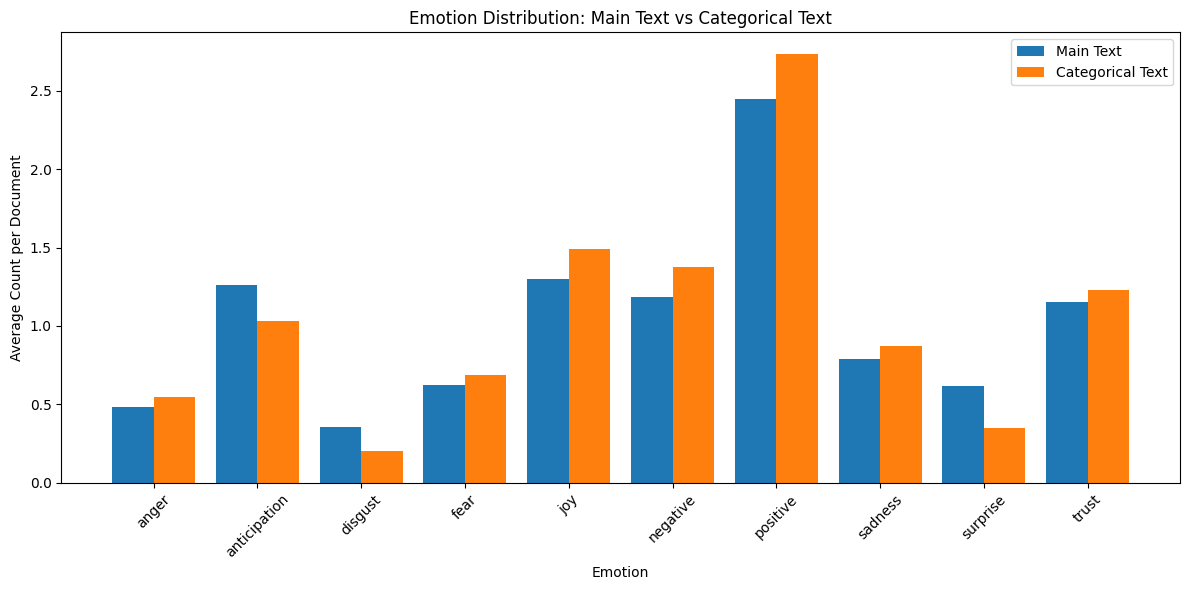

In [17]:
X_train_cat_lex = extract_lexicon_features(train_categorical_processed, emotion_lexicons)
X_val_cat_lex = extract_lexicon_features(val_categorical_processed, emotion_lexicons)
X_test_cat_lex = extract_lexicon_features(test_categorical_processed, emotion_lexicons)

print(f"Categorical lexicon features shape: {X_train_cat_lex.shape}")

# Compare emotion presence in main text vs categorical text
plt.figure(figsize=(12, 6))
width = 0.4
x = np.arange(len(emotion_names))
plt.bar(x - width/2, X_train_lex.mean(axis=0), width, label='Main Text')
plt.bar(x + width/2, X_train_cat_lex.mean(axis=0), width, label='Categorical Text')
plt.xticks(x, emotion_names, rotation=45)
plt.title('Emotion Distribution: Main Text vs Categorical Text')
plt.xlabel('Emotion')
plt.ylabel('Average Count per Document')
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Create Feature Combination Datasets

Now we'll create various combinations of features for model training and evaluation. This way we can evaluate which approach best captures the five sentiment categories.

From:
- **5.1** to **5.2**: Evaluate each feature type independently (Main Text-only or Categorical-only).
- **5.3** to **5.4**: Combine main text and categorical text processed with the same technique
- **5.5**: Combine different feature types that might complement each other
- **5.7**: Combine all available features to maximize signal

### 5.1 Text-only Features

These datasets use only the main text content, without any categorical metadata. This approach is crucial for real-world applications where typically only raw text is available without additional metadata.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `bow` | (1124, 1419) | Bag-of-Words features | Captures word frequency patterns in text |
| `tfidf` | (1124, 1419) | TF-IDF features | Weights words by importance and document frequency |
| `word2vec` | (1124, 100) | Word2Vec embeddings | Dense semantic vectors that capture word relationships |
| `lexicon` | (1124, 10) | NRC Lexicon features | Emotion-specific features based on lexicon matching |

These baseline representations allow us to evaluate which text feature extraction approach best captures sentiment information from raw text alone.

In [18]:
# Basic bag-of-words baseline
dataset_bow = {
    'train_X': X_train_bow,
    'val_X': X_val_bow,
    'test_X': X_test_bow,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Bag-of-Words features only'
}

# TF-IDF features
dataset_tfidf = {
    'train_X': X_train_tfidf,
    'val_X': X_val_tfidf,
    'test_X': X_test_tfidf,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'TF-IDF features only'
}

# Word2Vec features
dataset_w2v = {
    'train_X': X_train_w2v,
    'val_X': X_val_w2v,
    'test_X': X_test_w2v,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Word2Vec document embeddings only'
}

# Lexicon features
dataset_lex = {
    'train_X': X_train_lex,
    'val_X': X_val_lex,
    'test_X': X_test_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'NRC Lexicon features only'
}

### 5.2 Categorical Features Only

These datasets use only metadata (categorical information and intensity), completely ignoring the main text content. This allows us to test how much sentiment information is contained in these metadata fields.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `onehot` | (1124, 344) | One-hot encoded categories + intensity | Direct categorical representation with normalized intensity |
| `cat_bow` | (1124, 498) | Categorical text BoW | Bag-of-Words on categorical text |
| `cat_tfidf` | (1124, 498) | Categorical text TF-IDF | TF-IDF on categorical text |
| `cat_word2vec` | (1124, 50) | Categorical text Word2Vec | Word2Vec on categorical text |
| `cat_lexicon` | (1124, 10) | Categorical text NRC Lexicon | NRC Lexicon features on categorical text |
| `all_cat` | (1124, 902) | All categorical features combined | Comprehensive metadata representation |

This allows us to compare which categorical representation best captures sentiment information.

In [19]:
# One-hot encoded categorical features
dataset_onehot = {
    'train_X': X_train_cat_full,
    'val_X': X_val_cat_full,
    'test_X': X_test_cat_full,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'One-hot encoded categorical features + intensity'
}

# Bag-of-Words for categorical text
dataset_cat_bow = {
    'train_X': X_train_cat_bow,
    'val_X': X_val_cat_bow,
    'test_X': X_test_cat_bow,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Categorical text BoW features only'
}

# TF-IDF for categorical text
dataset_cat_tfidf = {
    'train_X': X_train_cat_tfidf,
    'val_X': X_val_cat_tfidf,
    'test_X': X_test_cat_tfidf,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Categorical text TF-IDF features only'
}

# Word2Vec for categorical text
dataset_cat_w2v = {
    'train_X': X_train_cat_w2v,
    'val_X': X_val_cat_w2v,
    'test_X': X_test_cat_w2v,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Categorical text Word2Vec features only'
}

# Lexicon for categorical text
dataset_cat_lex = {
    'train_X': X_train_cat_lex,
    'val_X': X_val_cat_lex,
    'test_X': X_test_cat_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Categorical text NRC Lexicon features only'
}

### 5.3 Combined Features - Text + Categorical with Same Feature Type

These datasets combine main text and categorical text using the same feature extraction technique. This maintains methodological consistency while leveraging both data sources.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `combined_bow` | (1124, 1917) | Text BoW + Categorical BoW | Maintains frequency-based representation across all text |
| `combined_tfidf` | (1124, 1917) | Text TF-IDF + Categorical TF-IDF | Consistent term weighting across all text sources |
| `combined_word2vec` | (1124, 150) | Text Word2Vec + Categorical Word2Vec | Consistent semantic representation across all text |
| `combined_lexicon` | (1124, 20) | Text Lexicon + Categorical Lexicon | Consistent emotion mapping across all text |

This tests whether maintaining the same feature extraction approach across all text sources provides effective sentiment classification.

In [20]:
# Combine BoW features
X_train_combined_bow = np.hstack([X_train_bow.toarray(), X_train_cat_bow.toarray()])
X_val_combined_bow = np.hstack([X_val_bow.toarray(), X_val_cat_bow.toarray()])
X_test_combined_bow = np.hstack([X_test_bow.toarray(), X_test_cat_bow.toarray()])

dataset_combined_bow = {
    'train_X': X_train_combined_bow,
    'val_X': X_val_combined_bow,
    'test_X': X_test_combined_bow,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Combined Text + Categorical BoW features'
}

# Combine TF-IDF features
X_train_combined_tfidf = np.hstack([X_train_tfidf.toarray(), X_train_cat_tfidf.toarray()])
X_val_combined_tfidf = np.hstack([X_val_tfidf.toarray(), X_val_cat_tfidf.toarray()])
X_test_combined_tfidf = np.hstack([X_test_tfidf.toarray(), X_test_cat_tfidf.toarray()])

dataset_combined_tfidf = {
    'train_X': X_train_combined_tfidf,
    'val_X': X_val_combined_tfidf,
    'test_X': X_test_combined_tfidf,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Combined Text + Categorical TF-IDF features'
}

# Combine Word2Vec features
X_train_combined_w2v = np.hstack([X_train_w2v, X_train_cat_w2v])
X_val_combined_w2v = np.hstack([X_val_w2v, X_val_cat_w2v])
X_test_combined_w2v = np.hstack([X_test_w2v, X_test_cat_w2v])

dataset_combined_w2v = {
    'train_X': X_train_combined_w2v,
    'val_X': X_val_combined_w2v,
    'test_X': X_test_combined_w2v,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Combined Text + Categorical Word2Vec features'
}

# Combine Lexicon features
X_train_combined_lex = np.hstack([X_train_lex, X_train_cat_lex])
X_val_combined_lex = np.hstack([X_val_lex, X_val_cat_lex])
X_test_combined_lex = np.hstack([X_test_lex, X_test_cat_lex])

dataset_combined_lex = {
    'train_X': X_train_combined_lex,
    'val_X': X_val_combined_lex,
    'test_X': X_test_combined_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Combined Text + Categorical Lexicon features'
}

### 5.4 Combined Features - Text Features + One-hot Encoded Categories

These datasets combine text-based features with one-hot encoded categorical data, providing a hybrid approach that leverages both text processing and direct categorical representation.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `tfidf_onehot` | (1124, 1763) | Text TF-IDF + One-hot categories | Combines rich text statistics with direct categorical encoding |
| `w2v_onehot` | (1124, 444) | Text Word2Vec + One-hot categories | Pairs semantic text representation with structured categories |
| `lex_onehot` | (1124, 354) | Text Lexicon + One-hot categories | Combines emotion-word mapping with explicit categories |

This approach tests whether the combination of processed text with structured categorical data improves performance over either approach alone.

In [21]:
# TF-IDF + One-hot encoded categories
X_train_tfidf_onehot = np.hstack([X_train_tfidf.toarray(), X_train_cat_full])
X_val_tfidf_onehot = np.hstack([X_val_tfidf.toarray(), X_val_cat_full])
X_test_tfidf_onehot = np.hstack([X_test_tfidf.toarray(), X_test_cat_full])

dataset_tfidf_onehot = {
    'train_X': X_train_tfidf_onehot,
    'val_X': X_val_tfidf_onehot,
    'test_X': X_test_tfidf_onehot,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Text TF-IDF + One-hot encoded categorical features'
}

# Word2Vec + One-hot encoded categories
X_train_w2v_onehot = np.hstack([X_train_w2v, X_train_cat_full])
X_val_w2v_onehot = np.hstack([X_val_w2v, X_val_cat_full])
X_test_w2v_onehot = np.hstack([X_test_w2v, X_test_cat_full])

dataset_w2v_onehot = {
    'train_X': X_train_w2v_onehot,
    'val_X': X_val_w2v_onehot,
    'test_X': X_test_w2v_onehot,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Text Word2Vec + One-hot encoded categorical features'
}

# Lexicon + One-hot encoded categories
X_train_lex_onehot = np.hstack([X_train_lex, X_train_cat_full])
X_val_lex_onehot = np.hstack([X_val_lex, X_val_cat_full])
X_test_lex_onehot = np.hstack([X_test_lex, X_test_cat_full])

dataset_lex_onehot = {
    'train_X': X_train_lex_onehot,
    'val_X': X_val_lex_onehot,
    'test_X': X_test_lex_onehot,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Text Lexicon + One-hot encoded categorical features'
}

### 5.5 Mixed Feature Combinations

These datasets explore unique combinations of feature types that might complement each other particularly well.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `tfidf_cat_w2v` | (1124, 1469) | Text TF-IDF + Categorical Word2Vec | Combines detailed text features with compact category semantics |
| `w2v_intensity` | (1124, 101) | Text Word2Vec + Intensity only | Tests whether emotional intensity enhances semantic text features |

These specialized pairings test specific hypotheses about feature complementarity for sentiment classification.

In [22]:
# TF-IDF + Categorical Word2Vec
X_train_tfidf_cat_w2v = np.hstack([X_train_tfidf.toarray(), X_train_cat_w2v])
X_val_tfidf_cat_w2v = np.hstack([X_val_tfidf.toarray(), X_val_cat_w2v])
X_test_tfidf_cat_w2v = np.hstack([X_test_tfidf.toarray(), X_test_cat_w2v])

dataset_tfidf_cat_w2v = {
    'train_X': X_train_tfidf_cat_w2v,
    'val_X': X_val_tfidf_cat_w2v,
    'test_X': X_test_tfidf_cat_w2v,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Text TF-IDF + Categorical Word2Vec features'
}

# Add intensity to combinations
X_train_w2v_intensity = np.hstack([X_train_w2v, X_train_intensity])
X_val_w2v_intensity = np.hstack([X_val_w2v, X_val_intensity])
X_test_w2v_intensity = np.hstack([X_test_w2v, X_test_intensity])

dataset_w2v_intensity = {
    'train_X': X_train_w2v_intensity,
    'val_X': X_val_w2v_intensity,
    'test_X': X_test_w2v_intensity,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Text Word2Vec + Intensity features'
}

### 5.6 Comprehensive Feature Combinations

These datasets represent our most complete feature integrations, combining multiple feature types to maximize available information.

| Dataset | Dimensions | Description | Rationale |
|---------|------------|-------------|-----------|
| `all_text` | (1124, 1529) | TF-IDF + Word2Vec + Lexicon | Combines all text feature types from section 5.1 |
| `all_cat` | (1124, 902) | All categorical features combined | Combines all categorical representations from section 5.2 |
| `all_features` | (1124, 2431) | Complete feature set | Combines all text and categorical representations |

These comprehensive combinations test whether maximizing available information improves classification performance.

The implementation uses `np.hstack()` to horizontally stack feature matrices. The conversion of sparse matrices to dense arrays (.toarray()) is necessary for compatibility with dense features like Word2Vec, though this couuld increase memory usage if the dataset was larger.

For understanding, we would get something like this simplified example:

Imagine we have a dataset with 2 features:
```
Example 1: "I feel happy today" (Sentiment: Positive)
Example 2: "This makes me angry" (Sentiment: Negative)
Example 3: "Not sure how I feel" (Sentiment: Ambiguous)
```
It would be processed into different feature types:
**TF-IDF**:
```
             'feel' 'happy' 'today' 'this' 'makes' 'angry' 'not' 'sure' 'how'
Example 1:   0.5    0.7     0.5     0.0    0.0     0.0     0.0   0.0    0.0
Example 2:   0.0    0.0     0.0     0.4    0.4     0.8     0.0   0.0    0.0
Example 3:   0.3    0.0     0.0     0.0    0.0     0.0     0.6   0.5    0.4
```
(A sparse matrix with shape (3, 9))

**Word2Vec**
```
            dim1  dim2  dim3  (etc up to ~100 dimensions)
Example 1:  0.02  0.14  -0.05  ...
Example 2:  -0.11 0.08  0.03   ...
Example 3:  0.01  -0.03 0.09   ...
```
(A dense matrix with shape (3, 100))

**Lexicon**:
```
            anger fear joy sadness surprise ...
Example 1:  0     0    2   0       0       ...
Example 2:  1     0    0   0       0       ...
Example 3:  0     0    0   0       1       ...
```
(A dense matrix with shape (3, 10) for 10 emotion categories)


The we convert to a dense array
```py
X_tfidf_dense = X_tfidf.toarray()
```

Then horizontally stack the matrices:
```py
X_combined = np.hstack([X_tfidf_dense, X_word2vec, X_lexicon])
```
which would get something like this:
```
Example 1: [0.5, 0.7, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.14, -0.05, ..., 0, 0, 2, 0, 0, ...]
               TF-IDF features                      |         Word2Vec         |    Lexicon features    
```

And in the end we are getting this number of features:

9 (TF-IDF) + 100 (Word2Vec) + 10 (Lexicon) = 119 features per example


In [23]:
# All text features combined (TF-IDF + Word2Vec + Lexicon)
X_train_all_text = np.hstack([X_train_tfidf.toarray(), X_train_w2v, X_train_lex])
X_val_all_text = np.hstack([X_val_tfidf.toarray(), X_val_w2v, X_val_lex])
X_test_all_text = np.hstack([X_test_tfidf.toarray(), X_test_w2v, X_test_lex])

dataset_all_text = {
    'train_X': X_train_all_text,
    'val_X': X_val_all_text,
    'test_X': X_test_all_text,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'All text features combined (TF-IDF + Word2Vec + Lexicon)'
}

# All categorical features combined (cat TF-IDF + cat Word2Vec + cat Lexicon + One-hot + Intensity)
X_train_all_cat = np.hstack([X_train_cat_tfidf.toarray(), X_train_cat_w2v, X_train_cat_lex, X_train_cat_full])
X_val_all_cat = np.hstack([X_val_cat_tfidf.toarray(), X_val_cat_w2v, X_val_cat_lex, X_val_cat_full])
X_test_all_cat = np.hstack([X_test_cat_tfidf.toarray(), X_test_cat_w2v, X_test_cat_lex, X_test_cat_full])

dataset_all_cat = {
    'train_X': X_train_all_cat,
    'val_X': X_val_all_cat,
    'test_X': X_test_all_cat,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'All categorical features combined'
}

# All features combined (Complete feature set)
X_train_all = np.hstack([
    X_train_tfidf.toarray(), X_train_w2v, X_train_lex,  # Text features
    X_train_cat_tfidf.toarray(), X_train_cat_w2v, X_train_cat_lex,  # Categorical text features
    X_train_cat_full  # One-hot encoded categories + intensity
])
X_val_all = np.hstack([
    X_val_tfidf.toarray(), X_val_w2v, X_val_lex,
    X_val_cat_tfidf.toarray(), X_val_cat_w2v, X_val_cat_lex,
    X_val_cat_full
])
X_test_all = np.hstack([
    X_test_tfidf.toarray(), X_test_w2v, X_test_lex,
    X_test_cat_tfidf.toarray(), X_test_cat_w2v, X_test_cat_lex,
    X_test_cat_full
])

dataset_all = {
    'train_X': X_train_all,
    'val_X': X_val_all,
    'test_X': X_test_all,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'All features combined (Text + Categorical + One-hot)'
}

### 5.7 Save All Datasets

In [24]:
# Organize and save all datasets
datasets = {
    # Text-only features
    'bow': dataset_bow,
    'tfidf': dataset_tfidf,
    'word2vec': dataset_w2v,
    'lexicon': dataset_lex,
    'all_text': dataset_all_text,
    
    # Categorical-only features
    'onehot': dataset_onehot,
    'cat_bow': dataset_cat_bow,
    'cat_tfidf': dataset_cat_tfidf,
    'cat_word2vec': dataset_cat_w2v,
    'cat_lexicon': dataset_cat_lex,
    'all_cat': dataset_all_cat,
    
    # Combined features with same approach
    'combined_bow': dataset_combined_bow,
    'combined_tfidf': dataset_combined_tfidf,
    'combined_word2vec': dataset_combined_w2v,
    'combined_lexicon': dataset_combined_lex,
    
    # Text + one-hot combinations
    'tfidf_onehot': dataset_tfidf_onehot,
    'w2v_onehot': dataset_w2v_onehot,
    'lex_onehot': dataset_lex_onehot,
    
    # Mixed combinations
    'tfidf_cat_w2v': dataset_tfidf_cat_w2v,
    'w2v_intensity': dataset_w2v_intensity,
    
    # All features
    'all_features': dataset_all
}

# Print dataset sizes and descriptions
for name, dataset in datasets.items():
    print(f"{name}: {dataset['train_X'].shape}, {dataset['description']}")

# Save datasets for model training
os.makedirs(project_root / 'data' / 'processed', exist_ok=True)
with open(project_root / 'data' / 'processed' / 'datasets.pkl', 'wb') as f:
    pickle.dump(datasets, f)

bow: (1124, 1420), Bag-of-Words features only
tfidf: (1124, 1420), TF-IDF features only
word2vec: (1124, 100), Word2Vec document embeddings only
lexicon: (1124, 10), NRC Lexicon features only
all_text: (1124, 1530), All text features combined (TF-IDF + Word2Vec + Lexicon)
onehot: (1124, 344), One-hot encoded categorical features + intensity
cat_bow: (1124, 480), Categorical text BoW features only
cat_tfidf: (1124, 480), Categorical text TF-IDF features only
cat_word2vec: (1124, 50), Categorical text Word2Vec features only
cat_lexicon: (1124, 10), Categorical text NRC Lexicon features only
all_cat: (1124, 884), All categorical features combined
combined_bow: (1124, 1900), Combined Text + Categorical BoW features
combined_tfidf: (1124, 1900), Combined Text + Categorical TF-IDF features
combined_word2vec: (1124, 150), Combined Text + Categorical Word2Vec features
combined_lexicon: (1124, 20), Combined Text + Categorical Lexicon features
tfidf_onehot: (1124, 1764), Text TF-IDF + One-hot en

## Feature Extraction Summary

We've created a comprehensive set of feature representations for emotion classification using multiple approaches:

### 1. Text-based Features
- **Bag-of-Words (BoW)**: Simple word frequency representation
- **TF-IDF**: Enhanced word frequency representation that highlights important terms
- **Word2Vec**: Dense vector representation capturing semantic relationships
- **NRC Emotion Lexicon**: Features based on emotional word associations

### 2. Categorical Features
We processed categorical features in two complementary ways:
- **Text-based approach**: Combined categorical fields into text and applied the same NLP techniques as for main text
- **One-hot encoding**: Direct categorical representation for primary_emotion, interaction_style, and context
- **Multi-hot encoding**: Special handling for secondary_emotions lists
- **Intensity normalization**: Scaled intensity values to [0-1] range

### 3. Combined Features
We created various combinations to evaluate which approach best captures emotional content:
- **Same-method combinations**: Main text and categorical text processed with the same technique
- **Text + one-hot combinations**: Text features with one-hot encoded categorical data
- **Mixed combinations**: Different feature types that complement each other
- **Comprehensive combinations**: All text features and all categorical features

This rich feature set allows us to systematically evaluate different representations and determine which aspects of the data are most informative for emotion classification. In the next notebook, we'll train and evaluate models using these feature sets to identify the optimal approach.